Dataset : Forest Cover Type Prediction
1. Data cleaning
2. EDA

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/forest-cover-type-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'forest-cover-type-dataset' dataset.
Path to dataset files: /kaggle/input/forest-cover-type-dataset


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("/kaggle/input/forest-cover-type-dataset/covtype.csv")

In [6]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [7]:
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Missing values per column:
Series([], dtype: int64)


In [8]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


OUTLIER DETECTION

In [9]:
import numpy as np

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove("Cover_Type")

In [11]:
from sklearn.ensemble import IsolationForest

In [12]:
iso = IsolationForest(contamination=0.01, random_state=42)

outliers = iso.fit_predict(df[numerical_cols])

df["outlier"] = outliers

In [13]:
print("Outliers detected:", (df["outlier"] == -1).sum())

Outliers detected: 5811


In [14]:
df_clean = df[df["outlier"] == 1].drop(columns=["outlier"])

In [15]:
print("Shape after outlier removal:", df_clean.shape)

Shape after outlier removal: (575201, 55)


CLASS DISTRIBUTION

In [16]:
class_counts = df_clean["Cover_Type"].value_counts().sort_index()

print(class_counts)

Cover_Type
1    211734
2    283139
3     31554
4      2387
5      9493
6     16451
7     20443
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt

%matplotlib inline

In [18]:
import seaborn as sns

In [19]:
sns.set_style("whitegrid")

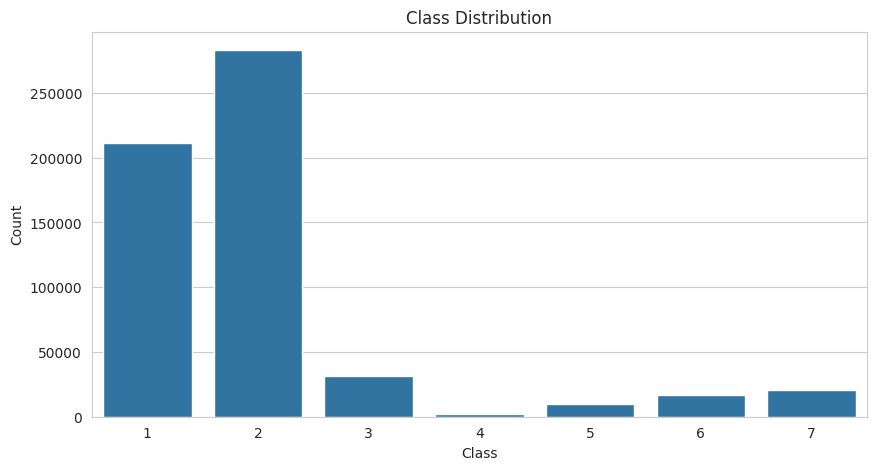

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [21]:
print("Class imbalance ratio:")
print(class_counts / class_counts.sum())

Class imbalance ratio:
Cover_Type
1    0.368104
2    0.492244
3    0.054857
4    0.004150
5    0.016504
6    0.028600
7    0.035541
Name: count, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X = df_clean.drop("Cover_Type", axis=1)
y = df_clean["Cover_Type"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train/Validation shape:", X_trainval.shape)
print("Test shape:", X_test.shape)

Train/Validation shape: (460160, 54)
Test shape: (115041, 54)


FEATURE DISTRIBUTION

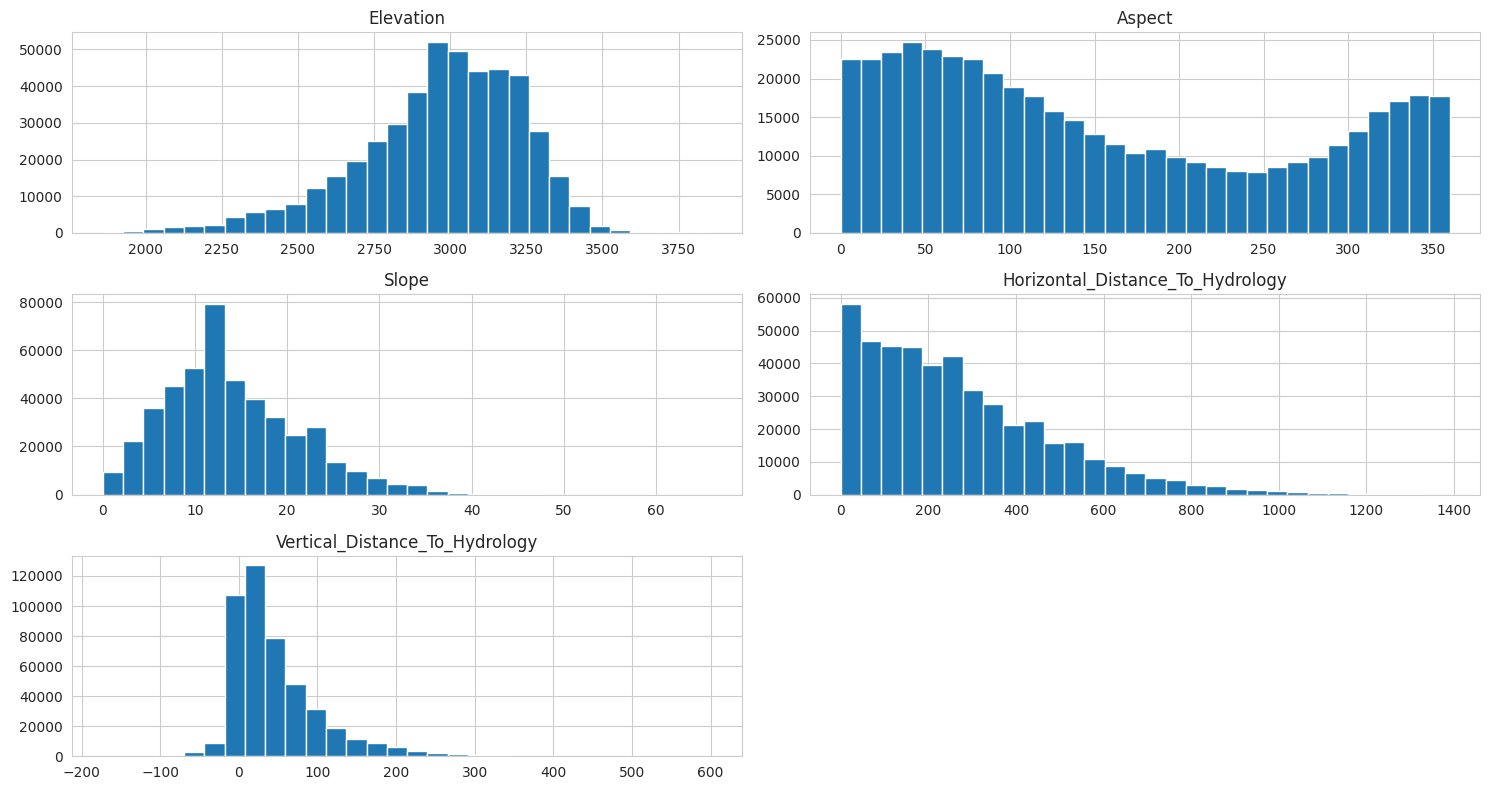

In [24]:
X_trainval[numerical_cols[:5]].hist(figsize=(15,8), bins=30)
plt.tight_layout()
plt.show()

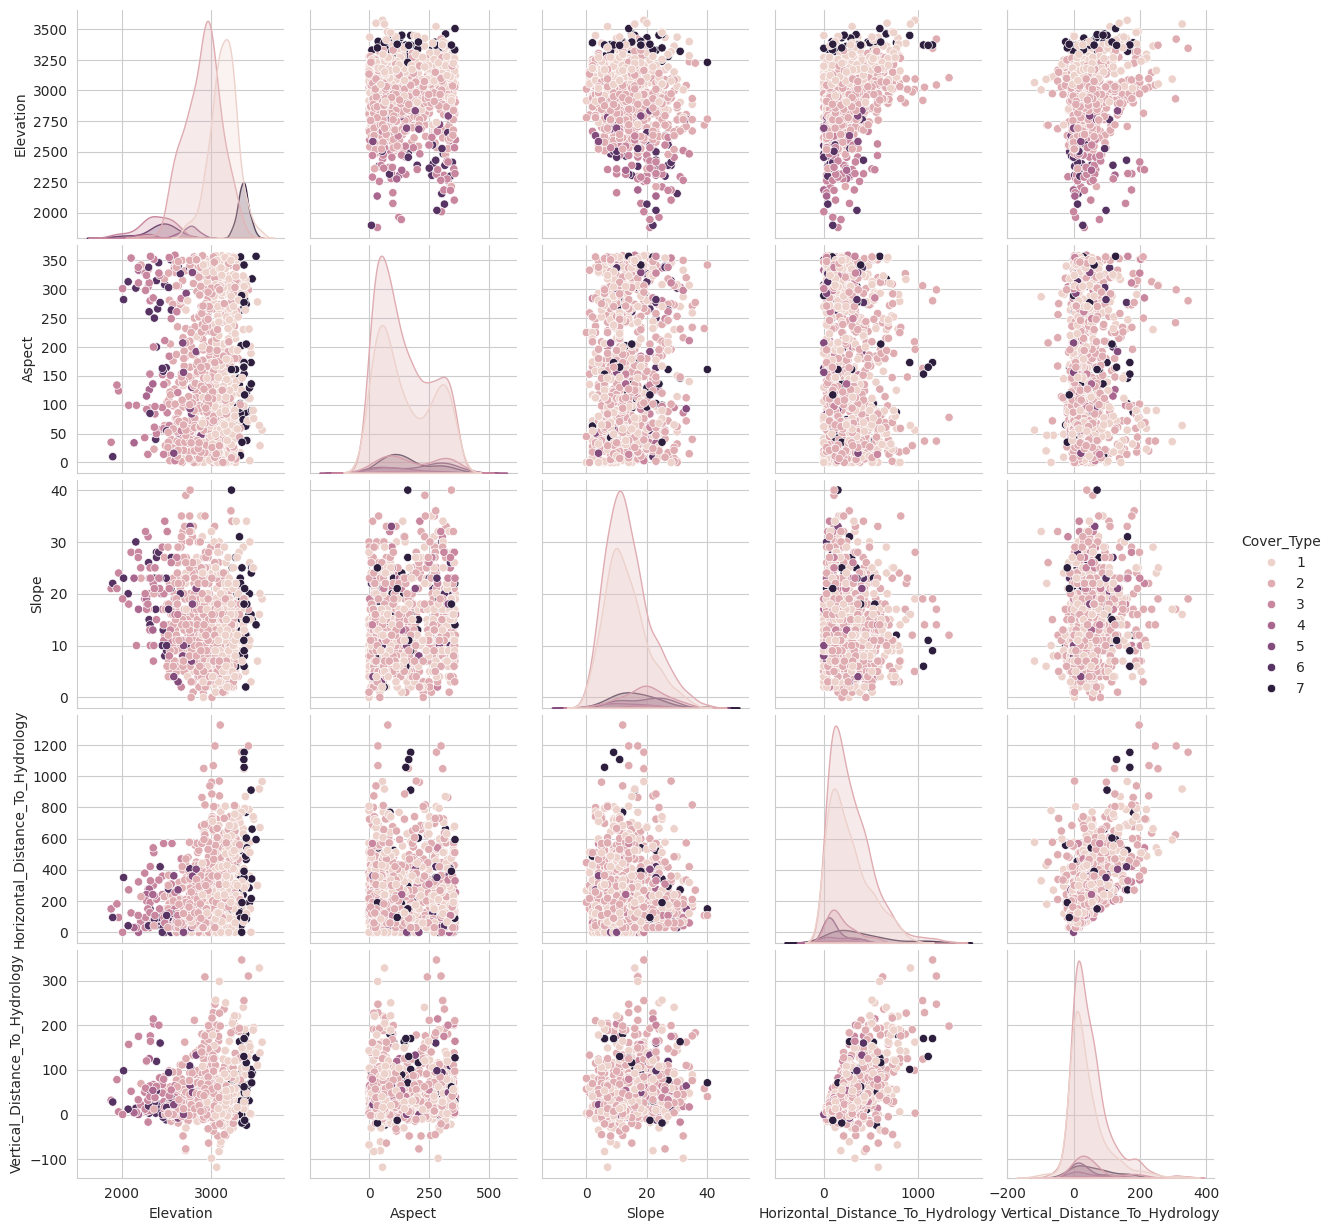

In [25]:
sample_df = X_trainval.sample(1000, random_state=42)
sample_df["Cover_Type"] = y_trainval.loc[sample_df.index]

sns.pairplot(
    sample_df.iloc[:, :5].join(sample_df["Cover_Type"]),
    hue="Cover_Type"
)
plt.show()